In [1]:
# Required packages
import numpy as np
import pandas as pd

# Import KModes as chosen Clustering methods
!pip install kmodes
from kmodes.kmodes import KModes

# Data Visualization
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

In [2]:
df = pd.read_csv('/content/preprocessed_unigame_time.csv')
df

,Your current CGPA?,Your current CGPA? (categorical),When you go to sleep?,Do you attend your morning class regularly?,The average time you spend playing games?,How many time you spend with family and friend?,Do you fill Fatigue?
0,2.0,Low,Late,No,Low,High,Yes
1,2.0,Low,Average,Yes,High,Moderate,No
2,2.0,Low,Late,No,High,Low,No
3,2.0,Low,Late,Yes,Moderate,Moderate,Yes
4,2.0,Low,Healthy,Yes,Moderate,Low,Yes
...,...,...,...,...,...,...,...
984,4.0,High,Average,Yes,Moderate,Moderate,No
985,4.0,High,Average,Yes,Moderate,Moderate,No
986,4.0,High,Average,Yes,High,Moderate,Yes
987,4.0,High,Healthy,Yes,High,Moderate,Yes


In [3]:
df.columns

Index(['Your  current CGPA?', 'Your  current CGPA? (categorical)',
       'When you go to sleep?', 'Do you attend your morning class regularly?',
       'The average time you spend playing games?',
       'How many time you spend with family and friend?',
       'Do you fill Fatigue?'],
      dtype='object')

In [5]:
df.rename(columns={'Your  current CGPA?': 'CGPA Numerical',
                   'Your  current CGPA? (categorical)' : 'CGPA Category',
                   'When you go to sleep?': 'Bed Time',
                   'Do you attend your morning class regularly?': 'Attend Morning Class',
                   'The average time you spend playing games?': 'Avg Game Time',
                   'How many time you spend with family and friend?': 'Social Time',
                   'Do you fill Fatigue?': 'Fatigue'
                   }, inplace = True)

df

,CGPA Numerical,CGPA Category,Bed Time,Attend Morning Class,Avg Game Time,Social Time,Fatigue
0,2.0,Low,Late,No,Low,High,Yes
1,2.0,Low,Average,Yes,High,Moderate,No
2,2.0,Low,Late,No,High,Low,No
3,2.0,Low,Late,Yes,Moderate,Moderate,Yes
4,2.0,Low,Healthy,Yes,Moderate,Low,Yes
...,...,...,...,...,...,...,...
984,4.0,High,Average,Yes,Moderate,Moderate,No
985,4.0,High,Average,Yes,Moderate,Moderate,No
986,4.0,High,Average,Yes,High,Moderate,Yes
987,4.0,High,Healthy,Yes,High,Moderate,Yes


In [7]:
# Dataset Dimensions: 989 records, 7 attributes.
df.shape

(989, 7)

Check for null values. Preprocessed dataset has no null values.

In [8]:
# Check for null values
print(df.isnull().sum(), "\n")

# Check for unique values in categorical columns to identify potential invalid entries
for col in df.select_dtypes(include='object').columns:
    print(f"Unique values in '{col}'".ljust(40) + f": {df[col].unique()}")


CGPA Numerical          0
CGPA Category           0
Bed Time                0
Attend Morning Class    0
Avg Game Time           0
Social Time             0
Fatigue                 0
dtype: int64 

Unique values in 'CGPA Category'        : ['Low' 'Average' 'High']
Unique values in 'Bed Time'             : ['Late' 'Average' 'Healthy' 'Very Late']
Unique values in 'Attend Morning Class' : ['No' 'Yes']
Unique values in 'Avg Game Time'        : ['Low' 'High' 'Moderate']
Unique values in 'Social Time'          : ['High' 'Moderate' 'Low']
Unique values in 'Fatigue'              : ['Yes' 'No']


**Global Features**

global_feature : retain all features/attributes included in original dataset, except for 'CGPA Numerical'. We only need 'CGPA Category'.

In [61]:
global_feature = df.copy()

In [62]:
global_feature.columns

Index(['CGPA Numerical', 'CGPA Category', 'Bed Time', 'Attend Morning Class',
       'Avg Game Time', 'Social Time', 'Fatigue'],
      dtype='object')

In [63]:
# Remove 'CGPA' column, just use 'CGPA (Categorical)'

global_feature = global_feature.drop('CGPA Numerical', axis=1)
global_feature.columns

Index(['CGPA Category', 'Bed Time', 'Attend Morning Class', 'Avg Game Time',
       'Social Time', 'Fatigue'],
      dtype='object')

#**Conduct K-Modes Clustering (Similar to Parent Dataset)**

**Workflow for conducting K-modes clustering**

1. Elbow curve to find optimal K (initialized clusters)
2. Select K-Mode initialization method: Cao (Preferred*)
3. Conduct clustering
4. Analysis & Visualization of Clustering Results


\

#Step 1: Elbow Curve to find Optimal K
1. Use Cao initialization method.
2. Test for K range (1, 10)
3. Measure cost
4. Plot elbow graph

Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 2917.0
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 2427.0
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 2142.0
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 1993.0
Initialization method and algorithm are deterministic. Setting n_init to 1.
Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, mov

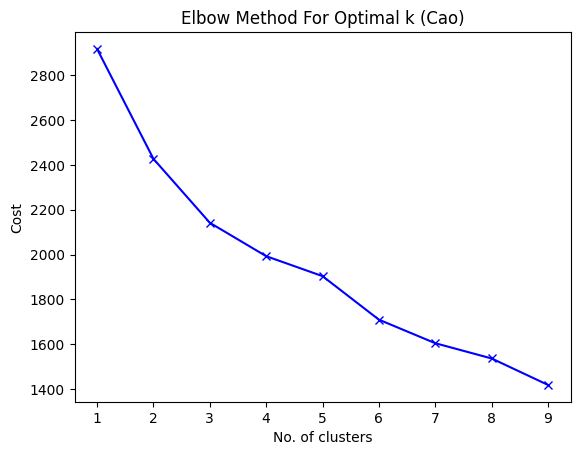

In [45]:
# Elbow curve to find optimal K (Cao)
cost_cao = []
K = range(1,10)

for num_clusters in list(K):
    kmode_cao = KModes(n_clusters=num_clusters, init = "Cao", n_init = 5, verbose=1)
    kmode_cao.fit_predict(global_feature)
    cost_cao.append(kmode_cao.cost_)

plt.plot(K, cost_cao, 'bx-')
plt.xlabel('No. of clusters')
plt.ylabel('Cost')
plt.title('Elbow Method For Optimal k (Cao)')
plt.show()

**Conclusion:**

Based on the elbow point, optimal choice is K = 4.

# 2. Select K-Mode initialization method & K Value
# 3. Conduct Clustering (Cao, K = 4)

In [46]:
km_cao = KModes(n_clusters=4, init = "Cao", n_init = 1, verbose=1)
global_fitcluster_cao = km_cao.fit_predict(global_feature)

Init: initializing centroids
Init: initializing clusters
Starting iterations...
Run 1, iteration: 1/100, moves: 0, cost: 1993.0


In [47]:
global_fitcluster_cao

array([1, 2, 1, 0, 3, 0, 1, 0, 0, 2, 1, 0, 0, 0, 1, 1, 0, 1, 3, 1, 0, 1,
       0, 2, 1, 0, 3, 0, 1, 0, 0, 0, 1, 1, 0, 1, 3, 1, 1, 0, 2, 1, 0, 3,
       0, 0, 1, 0, 0, 1, 0, 2, 1, 0, 0, 1, 0, 3, 1, 0, 1, 0, 0, 0, 0, 2,
       3, 2, 3, 2, 3, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 3, 3, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 2, 2, 0, 0, 0, 0, 0, 1,
       1, 1, 1, 1, 1, 2, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 2, 0, 2, 1, 1, 1,
       1, 1, 0, 0, 0, 1, 0, 3, 1, 0, 3, 3, 2, 1, 0, 1, 0, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 2, 1, 2, 1, 2, 1, 3, 3, 2, 0, 0, 2, 0, 2, 3, 0, 0, 0,
       1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 2, 2, 0, 0, 2, 2, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       3, 3, 3, 1, 1, 2, 2, 2, 1, 1, 3, 3, 3, 1, 1, 3, 0, 3, 0, 3, 0, 0,
       0, 2, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 3, 3, 0, 0, 0, 0, 2, 2, 2,
       1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,

In [52]:
global_cluster_centroids = pd.DataFrame(km_cao.cluster_centroids_)
global_cluster_centroids.columns = global_feature.columns
global_cluster_centroids


,CGPA Category,Bed Time,Attend Morning Class,Avg Game Time,Social Time,Fatigue
0,Average,Average,Yes,Moderate,Moderate,Yes
1,Low,Late,No,Low,Low,No
2,High,Average,No,High,Moderate,No
3,High,Healthy,Yes,Moderate,Low,No


From the results above, we can identify 4 major Clusters of students:\
\
Cluster 0:\
**Balanced academic performance** with average routines and moderate engagement in both gaming and social activities; experiences some fatigue, possibly due to moderate extracurricular involvement.
\
\
Cluster 1:\
**Lower academic performance**, late bedtimes, and low gaming and social activity; tends to avoid morning classes but reports low fatigue, indicating a preference for flexible schedules and possibly need time management improvement.
\
\
Cluster 2:\
**Good academic standing** with average sleep habits. Despite high gaming involvement, maintains moderate social time. Good at balancing academics with game activities.
\
\
Cluster 3:\
**High academic achievers** with disciplined routines, minimal gaming and social time, and low fatigue, suggesting a strong academic focus and efficient time management.

In [54]:
# Turn clustering results (global_fitcluster_cao) into dataframe
global_fitcluster_cao_df = pd.DataFrame(global_fitcluster_cao)
global_fitcluster_cao_df.columns = ['Cluster']


# Append predicted clustering results to global_feature's copy, global_feature_clustered
global_feature_clustered =  global_feature.copy()
global_feature_clustered['Cluster'] = global_fitcluster_cao_df
global_feature_clustered

,CGPA Category,Bed Time,Attend Morning Class,Avg Game Time,Social Time,Fatigue,Cluster
0,Low,Late,No,Low,High,Yes,1
1,Low,Average,Yes,High,Moderate,No,2
2,Low,Late,No,High,Low,No,1
3,Low,Late,Yes,Moderate,Moderate,Yes,0
4,Low,Healthy,Yes,Moderate,Low,Yes,3
...,...,...,...,...,...,...,...
984,High,Average,Yes,Moderate,Moderate,No,0
985,High,Average,Yes,Moderate,Moderate,No,0
986,High,Average,Yes,High,Moderate,Yes,0
987,High,Healthy,Yes,High,Moderate,Yes,0


# 4. Analyzing/Visualizing Clustering Results

**1. Clustering Results - Academics & Fatigue**
\
\
Cluster 0: **Average Performing Students** - Most students fall into the balanced lifestyle pattern with moderate engagement across all activities.
\
\
Cluster 1: **Low Performer Leisure Oriented Students** - Late bedtimes and moderate leisure activities but poor morning class attendance, suggesting that lifestyle choices significantly impact academic outcomes.
\
\
Cluster 2: **Elite Gamer Scholars** - Unique group of student who demonstrate strong academic performance alongside substantial engagement in gaming activities.
\
\
Cluster 3: **High Achieving Focused Student** - dominates the high CGPA category, representing the most academically successful group. Demonstrate disciplined behaviour with minimal gaming and social academic to focus on academics.

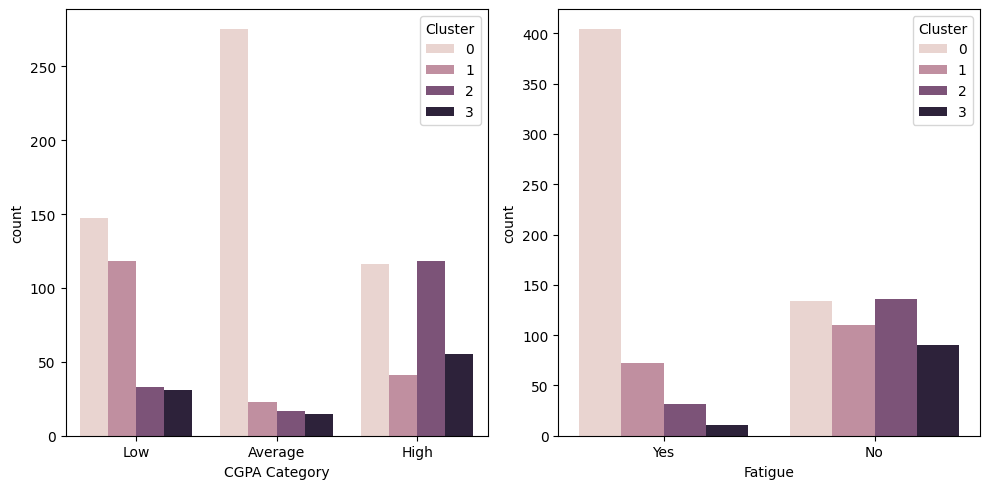

In [56]:
order_cgpa = ['Low', 'Average', 'High']

f, axs = plt.subplots(1,2,figsize = (10,5))

sns.countplot(x=global_feature_clustered['CGPA Category'],order=order_cgpa,hue=global_feature_clustered['Cluster'],ax=axs[0])
sns.countplot(x=global_feature_clustered['Fatigue'],order=global_feature_clustered['Fatigue'].value_counts().index,hue=global_feature_clustered['Cluster'],ax=axs[1])

plt.tight_layout()
plt.show()

**2. Clustering Results - Bed Time & Attend Morning Class**

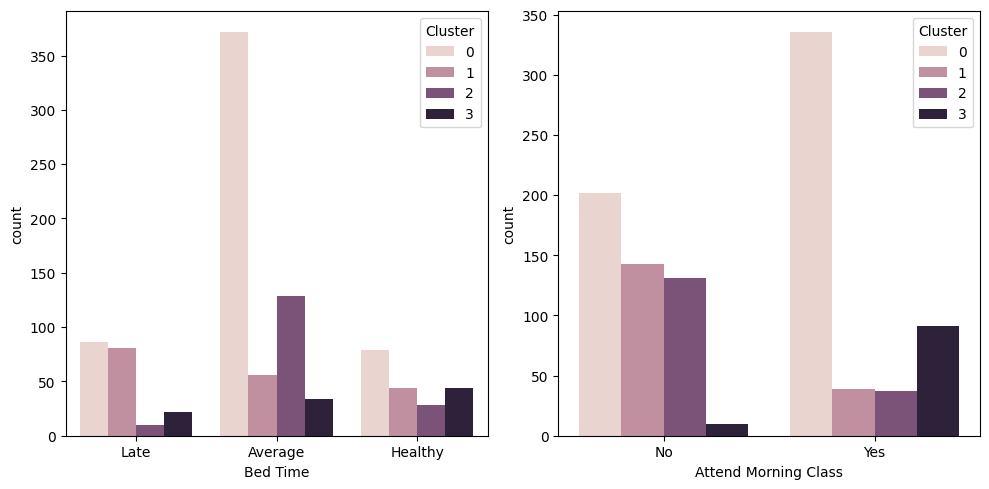

In [59]:
order_bedtime = ['Late', 'Average', 'Healthy']
order_class = ['No', 'Yes']

f, axs = plt.subplots(1,2,figsize = (10,5))

sns.countplot(x=global_feature_clustered['Bed Time'],order=order_bedtime,hue=global_feature_clustered['Cluster'],ax=axs[0])
sns.countplot(x=global_feature_clustered['Attend Morning Class'],order=order_class,hue=global_feature_clustered['Cluster'],ax=axs[1])

plt.tight_layout()
plt.show()

**3. Clustering Results - Average Game Time & Social Time**

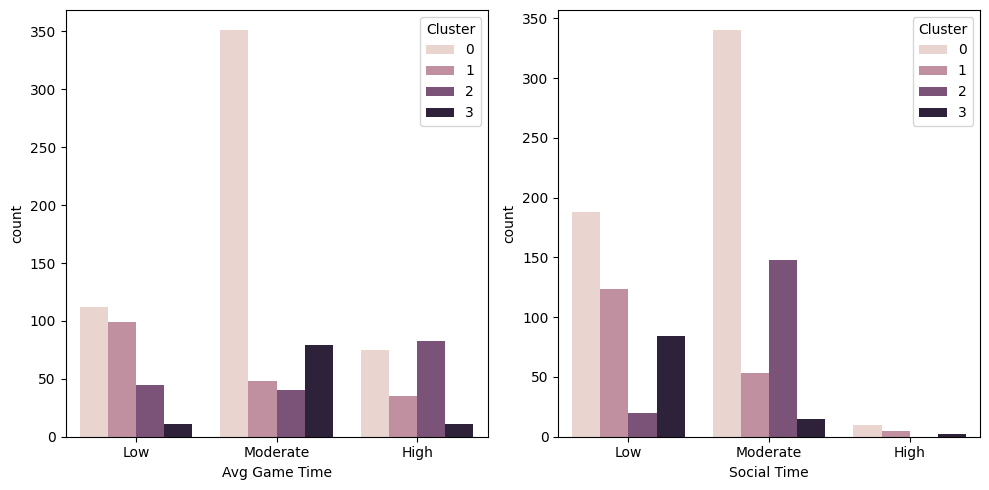

In [60]:
order_gametime = ['Low', 'Moderate', 'High']
order_socialtime = ['Low', 'Moderate', 'High']

f, axs = plt.subplots(1,2,figsize = (10,5))

sns.countplot(x=global_feature_clustered['Avg Game Time'],order=order_gametime,hue=global_feature_clustered['Cluster'],ax=axs[0])
sns.countplot(x=global_feature_clustered['Social Time'],order=order_socialtime,hue=global_feature_clustered['Cluster'],ax=axs[1])

plt.tight_layout()
plt.show()